# IA para Cibersegurança — Aulas 4 e 5
## Métricas, validação e um classificador de phishing de ponta a ponta

**Dupla:** `Maria Clara Miranda`  ·  `Evandro José`

> Rodem as células na ordem.

Nesta aula veremos:
- **Métricas e validação:** como saber se um modelo é *bom de verdade* em segurança (por que acurácia engana, precisão × recall, ROC/PR, limiar de decisão, validação sem vazamento).


Usamos uma base **real**: a **PhiUSIIL Phishing URL Dataset** (UCI, ~236 mil URLs), baixada direto em Python. Se o download falhar, o notebook cai automaticamente numa base real (PhiUSIIL) equivalente, para nunca travar a aula.

### 1. Bibliotecas e configuração

In [1]:
!pip install -q ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

### 2. A base de phishing (PhiUSIIL)
Cada linha é um site/URL descrito por dezenas de features extraídas da URL e do código-fonte da página. O rótulo original vem **invertido** (1 = legítimo, -1 = phishing); nós convertemos para `is_phishing` (1 = phishing).

In [2]:
# Base real: UCI Phishing Websites (Mohammad et al., id=327)
# Rótulo original: coluna 'Result' com 1 = LEGÍTIMO e -1 = PHISHING.
RANDOM_SEED = 33
import numpy as np, pandas as pd
np.random.seed(RANDOM_SEED)

def carregar_uci_phishing():
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=327)
    X = ds.data.features.copy()
    y = ds.data.targets.copy()
    df = pd.concat([X, y], axis=1)
    df.columns = [str(c).strip() for c in df.columns]

    # a coluna de rótulo costuma se chamar 'Result' (ou 'result')
    col_rotulo = [c for c in df.columns if c.lower() in ('result', 'class', 'label')][0]
    # -1 (phishing) -> 1 ; 1 (legítimo) -> 0
    df['is_phishing'] = (df[col_rotulo] == -1).astype(int)
    df = df.drop(columns=[col_rotulo])

    # aqui todas as features já são numéricas; mantemos só numéricas por segurança
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    df = df[num]
    return df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

def gerar_base_sintetica():
    rng = np.random.default_rng(RANDOM_SEED)
    nl, npish = 8000, 2500
    legit = pd.DataFrame({
        'url_length': np.clip(rng.normal(52,24,nl),5,None), 'num_dots': np.clip(rng.normal(2.8,1.4,nl),0,None),
        'num_subdominios': np.clip(rng.normal(1.4,1.0,nl),0,None), 'tem_ip_na_url': (rng.random(nl)<0.06).astype(int),
        'tem_arroba': (rng.random(nl)<0.08).astype(int), 'tem_https': (rng.random(nl)<0.78).astype(int),
        'idade_dominio_dias': np.clip(rng.normal(1100,850,nl),1,None), 'num_chars_especiais': np.clip(rng.normal(4,3,nl),0,None),
        'palavras_suspeitas': rng.poisson(0.6,nl), 'num_redirecionamentos': rng.poisson(0.7,nl)}); legit['is_phishing']=0
    phish = pd.DataFrame({
        'url_length': np.clip(rng.normal(66,28,npish),5,None), 'num_dots': np.clip(rng.normal(3.7,1.7,npish),0,None),
        'num_subdominios': np.clip(rng.normal(2.1,1.3,npish),0,None), 'tem_ip_na_url': (rng.random(npish)<0.20).astype(int),
        'tem_arroba': (rng.random(npish)<0.22).astype(int), 'tem_https': (rng.random(npish)<0.62).astype(int),
        'idade_dominio_dias': np.clip(rng.normal(380,400,npish),1,None), 'num_chars_especiais': np.clip(rng.normal(6.5,4.5,npish),0,None),
        'palavras_suspeitas': rng.poisson(1.5,npish), 'num_redirecionamentos': rng.poisson(1.3,npish)}); phish['is_phishing']=1
    return pd.concat([legit,phish],ignore_index=True).sample(frac=1,random_state=RANDOM_SEED).reset_index(drop=True)

try:
    df = carregar_uci_phishing()
    print('Base: UCI Phishing Websites (real).')
except Exception as e:
    print('Falha ao baixar a UCI (', type(e).__name__, ') -> usando base sintética.')
    df = gerar_base_sintetica()

Base: UCI Phishing Websites (real).


### 3. EDA rápida
O primeiro reflexo: **quão desbalanceada** é a base?

/tmp/ipykernel_1800/852752903.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Legítimo', 'Phishing']); ax[1].set_title(f'{feat} por classe')


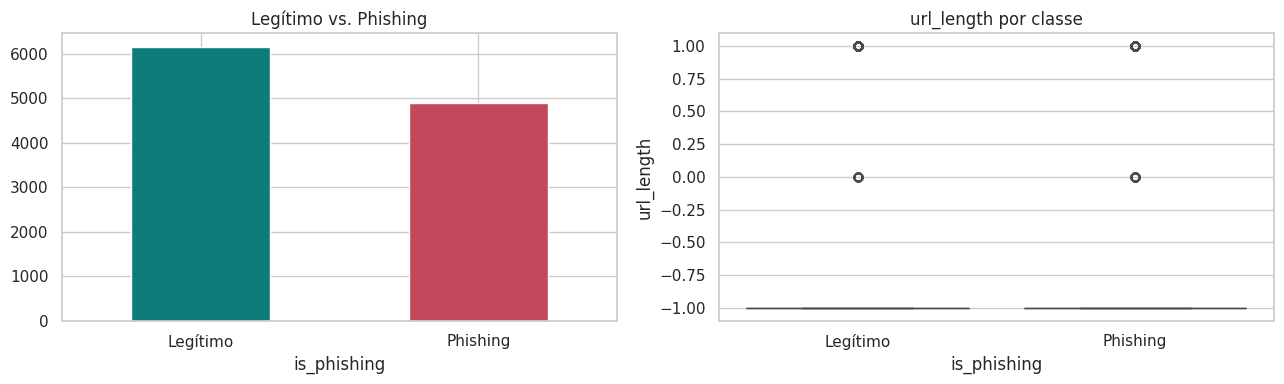

Feature comparada: url_length


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['is_phishing'].map({0:'Legítimo', 1:'Phishing'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#0E7C7B', '#C1495B'])
ax[0].set_title('Legítimo vs. Phishing'); ax[0].tick_params(axis='x', rotation=0)

# escolhe uma feature de tamanho da URL que exista (real ou sintética)
cand = [c for c in ['URLLength', 'url_length', 'DomainLength'] if c in df.columns]
feat = cand[0] if cand else df.drop(columns='is_phishing').columns[0]
sns.boxplot(data=df, x='is_phishing', y=feat, ax=ax[1])
ax[1].set_xticklabels(['Legítimo', 'Phishing']); ax[1].set_title(f'{feat} por classe')
plt.tight_layout(); plt.show()
print('Feature comparada:', feat)

**O que observar:** veja se as classes estão desbalanceadas e se a feature escolhida já separa visualmente phishing de legítimo. Guardem a proporção — é a chave da próxima célula.

### 4. Por que acurácia engana
Antes de treinar qualquer modelo: e se a gente **chutasse “legítimo” para tudo**?

In [4]:
baseline_acc = (df['is_phishing'] == 0).mean()
print(f'Classe majoritária = legítimo ({baseline_acc:.1%} da base).')
print(f'Um "modelo" que sempre diz LEGÍTIMO teria acurácia de {baseline_acc:.1%}...')
print('...e não detectaria UM ÚNICO phishing. Por isso acurácia sozinha não serve.')

Classe majoritária = legítimo (55.7% da base).
Um "modelo" que sempre diz LEGÍTIMO teria acurácia de 55.7%...
...e não detectaria UM ÚNICO phishing. Por isso acurácia sozinha não serve.


### 5. Preparação e split (sem vazamento)
Separamos treino e teste **antes** de qualquer ajuste. Essa ordem evita **data leakage**: o modelo nunca pode “espiar” o teste. Usamos `stratify` para manter a proporção de phishing nos dois lados.

In [5]:
X = df.drop(columns='is_phishing')
y = df['is_phishing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Phishing — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (7738, 30) | Teste: (3317, 30)
Phishing — treino: 44.3% | teste: 44.3%


### 6. Treinar um modelo
Usamos Random Forest (já conhecido da Aula 3). O foco hoje não é o modelo — é **como avaliá-lo**.

In [6]:
rf = RandomForestClassifier(n_estimators=150, class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]   # probabilidade de ser phishing
print('Modelo treinado.')

Modelo treinado.


### 7. Matriz de confusão
Os quatro números que explicam tudo. Em phishing:
- **Falso positivo (FP):** site legítimo marcado como phishing → usuário bloqueado à toa.
- **Falso negativo (FN):** phishing que passou como legítimo → usuário exposto ao golpe.

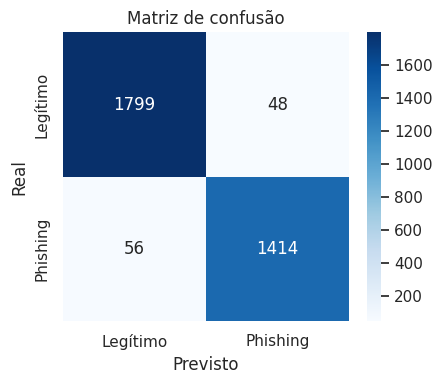

Verdadeiros phishing detectados (TP): 1414
Phishing que passaram   (FN): 56   <- os mais perigosos
Alarmes falsos          (FP): 48


In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Phishing'], yticklabels=['Legítimo', 'Phishing'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros phishing detectados (TP): {tp}')
print(f'Phishing que passaram   (FN): {fn}   <- os mais perigosos')
print(f'Alarmes falsos          (FP): {fp}')

### 8. Precisão, recall e F1
- **Precisão:** dos que o modelo *chamou de phishing*, quantos eram mesmo? (evita alarme falso)
- **Recall:** dos phishing *que existiam*, quantos o modelo pegou? (evita deixar passar)
- **F1:** equilíbrio entre os dois.

In [8]:
# Cálculo direto dos phishings identificados
tp = ((y_pred == 1) & (y_test == 1)).sum()  # Phishings reais detectados (Verdadeiros Positivos)
total_phish_reais = (y_test == 1).sum()    # Total de phishings existentes no teste
total_alertas = (y_pred == 1).sum()        # Total sinalizado como phishing pelo modelo (TP + FP)

print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Phishing']))
print(f'Phishing detectados (TP) : {tp} de {total_phish_reais} reais (Alertas emitidos: {total_alertas})')
print(f'Acurácia                 : {accuracy_score(y_test, y_pred):.3f}   (baseline "tudo legítimo": {baseline_acc:.3f})')
print(f'Precisão                 : {precision_score(y_test, y_pred):.3f}')
print(f'Recall                   : {recall_score(y_test, y_pred):.3f}   <- o modelo deixou passar parte dos phishing')
print(f'F1                       : {f1_score(y_test, y_pred):.3f}')

              precision    recall  f1-score   support

    Legítimo       0.97      0.97      0.97      1847
    Phishing       0.97      0.96      0.96      1470

    accuracy                           0.97      3317
   macro avg       0.97      0.97      0.97      3317
weighted avg       0.97      0.97      0.97      3317

Phishing detectados (TP) : 1414 de 1470 reais (Alertas emitidos: 1462)
Acurácia                 : 0.969   (baseline "tudo legítimo": 0.557)
Precisão                 : 0.967
Recall                   : 0.962   <- o modelo deixou passar parte dos phishing
F1                       : 0.965


**O que observar:** a acurácia parece boa, mas o **recall** revela que o modelo deixa passar uma fatia dos phishing. É esse tipo de erro que queremos reduzir, o que nos leva ao **limiar**.

### 9. ROC-AUC e PR-AUC
Métricas que olham o modelo em **todos os limiares** de uma vez.
- **ROC-AUC:** capacidade geral de separar as classes.
- **PR-AUC:** foca na classe rara (phishing).

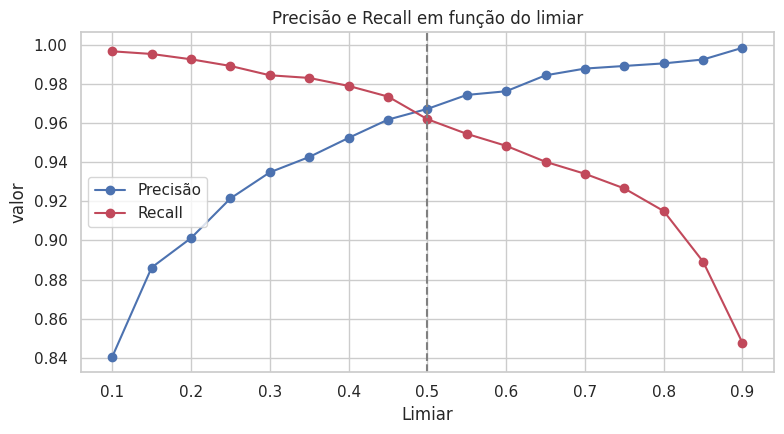

limiar 0.3:  precisão 0.93  |  recall 0.98
limiar 0.5:  precisão 0.97  |  recall 0.96
limiar 0.7:  precisão 0.99  |  recall 0.93


In [9]:
limiares = np.arange(0.1, 0.91, 0.05)
precisoes = [precision_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in limiares]
recalls   = [recall_score(y_test, (y_proba >= t).astype(int)) for t in limiares]

plt.figure(figsize=(8, 4.5))
plt.plot(limiares, precisoes, 'o-', label='Precisão')
plt.plot(limiares, recalls,   'o-', label='Recall', color='#C1495B')
plt.axvline(0.5, ls='--', color='gray'); plt.xlabel('Limiar'); plt.ylabel('valor')
plt.title('Precisão e Recall em função do limiar'); plt.legend(); plt.tight_layout(); plt.show()

for t in [0.3, 0.5, 0.7]:
    p = (y_proba >= t).astype(int)
    print(f'limiar {t}:  precisão {precision_score(y_test,p,zero_division=0):.2f}  |  recall {recall_score(y_test,p):.2f}')

### 10. O limiar de decisão e o custo dos erros
Por padrão o modelo chama de phishing quando a probabilidade ≥ 0,5. Mas **nós escolhemos esse corte**. Baixá-lo pega mais phishing (recall ↑) ao custo de mais alarmes falsos (precisão ↓).

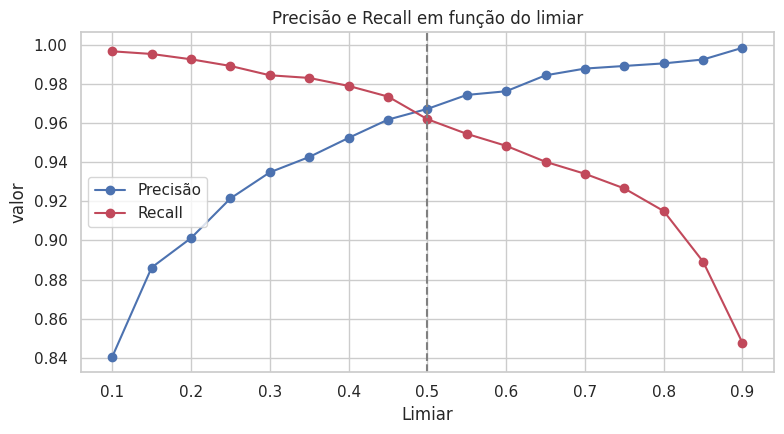

limiar 0.3:  precisão 0.93  |  recall 0.98
limiar 0.5:  precisão 0.97  |  recall 0.96
limiar 0.7:  precisão 0.99  |  recall 0.93


In [10]:
limiares = np.arange(0.1, 0.91, 0.05)
precisoes = [precision_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in limiares]
recalls   = [recall_score(y_test, (y_proba >= t).astype(int)) for t in limiares]

plt.figure(figsize=(8, 4.5))
plt.plot(limiares, precisoes, 'o-', label='Precisão')
plt.plot(limiares, recalls,   'o-', label='Recall', color='#C1495B')
plt.axvline(0.5, ls='--', color='gray'); plt.xlabel('Limiar'); plt.ylabel('valor')
plt.title('Precisão e Recall em função do limiar'); plt.legend(); plt.tight_layout(); plt.show()

for t in [0.3, 0.5, 0.7]:
    p = (y_proba >= t).astype(int)
    print(f'limiar {t}:  precisão {precision_score(y_test,p,zero_division=0):.2f}  |  recall {recall_score(y_test,p):.2f}')

**Decisão de segurança:** se deixar passar phishing é o pior erro, escolhemos um limiar **mais baixo**, então, aceitamos mais alarmes falsos para não perder golpes. Não existe “limiar certo” universal: depende do custo de cada erro.

### 11. Validação mais robusta: validação cruzada
Um único split pode dar sorte (ou azar). A **validação cruzada** treina/testa em várias divisões e mostra o desempenho médio — mais confiável.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores = cross_val_score(rf, X, y, cv=cv, scoring='f1')
print('F1 em cada divisão:', scores.round(3))
print(f'F1 médio: {scores.mean():.3f}  (±{scores.std():.3f})')

F1 em cada divisão: [0.961 0.972 0.965 0.961 0.971]
F1 médio: 0.966  (±0.005)


### Protocolo de avaliação (entregável da Parte A)
Fechamos aqui o **protocolo** que vamos usar no projeto:
- **Split:** treino/teste estratificado, feito **antes** de qualquer ajuste (sem vazamento).
- **Métrica principal:** recall de phishing (não deixar passar), acompanhada de precisão e F1.
- **Métrica global:** PR-AUC (mais honesta que acurácia no desbalanceamento).
- **Limiar:** escolhido conforme o custo dos erros, não fixo em 0,5.
- **Robustez:** validação cruzada de 5 divisões.

### 12. As features de phishing
Cada feature tenta capturar um “sinal” que costuma diferenciar um golpe de um site real.

In [12]:
resumo = df.groupby('is_phishing').mean().T
resumo.columns = ['Legítimo (média)', 'Phishing (média)']
resumo.round(2)

,Legítimo (média),Phishing (média)
having_ip_address,0.39,0.21
url_length,-0.59,-0.68
shortining_service,0.70,0.79
having_at_symbol,0.73,0.66
double_slash_redirecting,0.72,0.77
prefix_suffix,-0.52,-1.00
having_sub_domain,0.28,-0.21
sslfinal_state,0.83,-0.48
domain_registration_length,-0.53,-0.10
favicon,0.63,0.63


**O que observar:** URLs de phishing tendem a ser mais longas, com mais pontos/subdomínios, mais palavras suspeitas e domínios muito mais novos. São esses contrastes que o modelo aprende.

### 13. Quais features pesaram mais?

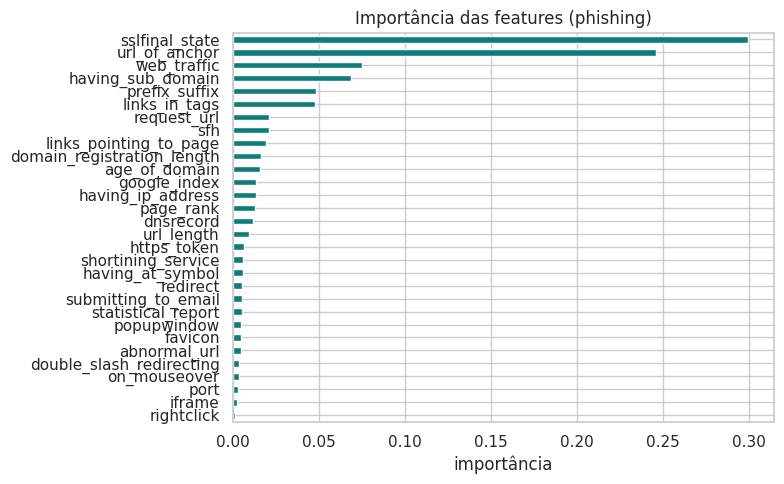

,0
sslfinal_state,0.300
url_of_anchor,0.246
web_traffic,0.075
having_sub_domain,0.069
prefix_suffix,0.048
links_in_tags,0.048
request_url,0.021
sfh,0.021
links_pointing_to_page,0.019
domain_registration_length,0.016


In [13]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importancias[::-1].plot(kind='barh', color='#0E7C7B')
plt.title('Importância das features (phishing)'); plt.xlabel('importância'); plt.tight_layout(); plt.show()
importancias.round(3)

### 14. Aplicar o protocolo
Treinamos o modelo final e o avaliamos **exatamente segundo o protocolo** definido na Parte A: split estratificado, recall como métrica principal, limiar ajustado ao custo do erro.

In [14]:
# 1. Escolha o limiar desejado
LIMIAR = 0.2

# 2. Recalcule a previsão com base nas probabilidades salvas
y_final = (y_proba >= LIMIAR).astype(int)

# 3. Exiba as métricas atualizadas
print(
    f"=== Avaliação para Limiar {LIMIAR} (Total de Phishing Detectado:"
    f" {y_final.sum()}) ==="
)
print(
    classification_report(
        y_test, y_final, target_names=["Legítimo", "Phishing"]
    )
)

=== Avaliação para Limiar 0.2 (Total de Phishing Detectado: 1620) ===
              precision    recall  f1-score   support

    Legítimo       0.99      0.91      0.95      1847
    Phishing       0.90      0.99      0.94      1470

    accuracy                           0.95      3317
   macro avg       0.95      0.95      0.95      3317
weighted avg       0.95      0.95      0.95      3317



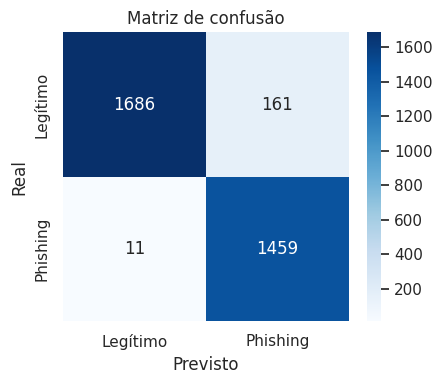

Verdadeiros phishing detectados (TP): 1459
Phishing que passaram   (FN): 11   <- os mais perigosos
Alarmes falsos          (FP): 161


In [15]:
cm = confusion_matrix(y_test, y_final)
plt.figure(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Phishing'], yticklabels=['Legítimo', 'Phishing'])
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusão'); plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros phishing detectados (TP): {tp}')
print(f'Phishing que passaram   (FN): {fn}   <- os mais perigosos')
print(f'Alarmes falsos          (FP): {fp}')

In [16]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def analisar_tradeoff_limiares(y_true, y_probs, limiar_padrao=0.50, limiar_novo=0.20):
    comparacao = []

    for t in [limiar_padrao, limiar_novo]:
        preds = (y_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

        prec = precision_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds)
        acc = accuracy_score(y_true, preds)
        especificidade = tn / (tn + fp)

        comparacao.append({
            'Limiar': f'{t:.2f}',
            'Phishing Detectado (TP)': tp,
            'Phishing Perdido (FN)': fn,
            'Alarmes Falsos (FP)': fp,
            'Precisão': f'{prec:.2%}',
            'Recall': f'{rec:.2%}',
            'Especificidade': f'{especificidade:.2%}',
            'Acurácia Geral': f'{acc:.2%}'
        })

    df_resultado = pd.DataFrame(comparacao).set_index('Limiar')
    return df_resultado

# Executa a comparação usando as variáveis do seu notebook
df_tradeoff = analisar_tradeoff_limiares(y_test, y_proba, limiar_padrao=0.50, limiar_novo=0.20)
display(df_tradeoff)



,Phishing Detectado (TP),Phishing Perdido (FN),Alarmes Falsos (FP),Precisão,Recall,Especificidade,Acurácia Geral
Limiar,,,,,,,
0.50,1414,56,48,96.72%,96.19%,97.40%,96.86%
0.20,1459,11,161,90.06%,99.25%,91.28%,94.81%


## Análise do trade-off entre os limiares 0.50 e 0.20

Compare os resultados obtidos utilizando os dois limiares.

### 1. Recall

O Recall passou de **96,2% (limiar 0.50) para 99,25% (limiar 0.20)**.

**Pergunta:**  
O que essa alteração indica sobre a capacidade do modelo de detectar ataques?

**Resposta:**  
> Diminuir o limiar de decisão torna o modelo mais "desconfiado": ele passa a classificar como phishing qualquer URL com uma probabilidade menor de ser maliciosa, exigindo menos certeza para soar o alarme. Isso aumenta o Recall porque o modelo passa a capturar quase todos os phishings reais (de 1470 phishings do teste, foram detectados 1459 — ficaram só 11 sem detectar). Ou seja, o modelo melhora sua capacidade de não deixar ataques passarem despercebidos, o que é o objetivo principal em um sistema de segurança, onde um ataque não detectado costuma ser mais custoso que um alarme falso.

### 2. Falsos Negativos

Os Falsos Negativos passaram de **56 (limiar 0.50) para 11 (limiar 0.20)**.

**Pergunta:**  
O que representa essa redução? Por que esse resultado é importante em um sistema de detecção de phishing?

**Resposta:**  
> Um Falso Negativo é um phishing real que o modelo classificou como legítimo — o pior tipo de erro num sistema de segurança, porque o ataque passa despercebido e o usuário fica exposto sem nenhum alerta. Reduzir esse número de 56 para 11 significa que, no limiar mais baixo, quase todos os phishings do conjunto de teste foram capturados. Em um cenário real, cada Falso Negativo evitado é um usuário a menos exposto a roubo de credenciais, fraude financeira ou instalação de malware — por isso, mesmo custando mais alarmes falsos, essa redução costuma valer a pena em contextos de segurança.

### 3. Falsos Positivos

Os Falsos Positivos passaram de **48 (limiar 0.50) para 161 (limiar 0.20)**.

**Pergunta:**  
Qual é o impacto desse aumento para os usuários e para a operação do sistema?

**Resposta:**  
> Um Falso Positivo é um site legítimo classificado como phishing — o usuário é bloqueado ou alertado sem necessidade. Esse aumento de 48 para 161 tem custo direto na experiência do usuário (mais bloqueios incômodos, possível perda de confiança no sistema, gente ignorando os alertas com o tempo) e também custo operacional, já que cada alarme falso costuma gerar trabalho extra para a equipe de segurança investigar ou liberar manualmente. É o preço pago pelo modelo ter ficado mais sensível na detecção de phishing: ele passa a errar mais para o lado de "desconfiar demais".

### 4. Precisão e Recall

| Métrica | Limiar 0.50 | Limiar 0.20 |
|---|---:|---:|
| Recall | 96,2% | 99,25% |
| Precisão | 96,7% | 90,0% |

**Pergunta:**  
Por que o Recall aumentou enquanto a Precisão diminuiu?

**Resposta:**  
> Recall e Precisão puxam em direções opostas quando o limiar muda, porque medem tipos de erro diferentes. Baixar o limiar faz o modelo classificar mais casos como "phishing", o que aumenta o Recall (mais phishings reais são capturados, já que basta menos evidência para o alarme disparar) mas também aumenta o número de sites legítimos classificados erroneamente como phishing, derrubando a Precisão (proporção de alertas que são de fato phishing verdadeiro). Esse é o trade-off central em detecção de ameaças: não existe um limiar que maximize as duas métricas ao mesmo tempo — a escolha depende de qual erro custa mais caro no contexto de uso (deixar um ataque passar vs. incomodar o usuário com um alarme falso).

## Checklist do entregável de hoje

- [x] Base carregada e explorada (proporção de classes)
- [x] Split sem vazamento + modelo treinado
- [x] Matriz de confusão e métricas por classe interpretadas
- [x] ROC-AUC / PR-AUC e efeito do limiar analisados
- [x] Validação cruzada executada
- [x] **Protocolo de avaliação** definido e aplicado ao classificador final
- [x] Respostas da discussão registradas no notebook

**Próxima aula:** detecção de anomalias, UEBA e SOC — encontrar comportamento suspeito **sem** rótulos.